## Automated Business Insights

This notebook automatically generates business insights from aggregated metrics using Python.  
These insights simulate AI-assisted analytics by translating quantitative results into business explanations.

In [3]:
# import libraries

import pandas as pd
import json

In [4]:
# Load Dataset

orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")

In [5]:
# Create Revenue Column

order_items["revenue"] = order_items["quantity"] * order_items["price_at_purchase"]

order_items.head()

,order_item_id,order_id,product_id,quantity,price_at_purchase,item_status,rand_val,revenue
0,1,1,167,3,3452.41,Returned,0.008142,10357.23
1,2,1,70,1,2372.78,Returned,0.045928,2372.78
2,3,2,87,2,7499.93,Returned,0.205213,14999.86
3,4,2,26,2,1825.30,Completed,0.888281,3650.60
4,5,2,118,2,4610.05,Completed,0.825768,9220.10


In [6]:
# Merge Tables

# order_items with orders
sales = order_items.merge(orders, on="order_id",how="left")

# with products
sales = sales.merge(products, on="product_id", how="left")

sales.head()

,order_item_id,order_id,product_id,quantity,price_at_purchase,item_status,rand_val,revenue,customer_id,order_date,order_status,payment_method,product_name,category,sub_category,gender,price,weight_bucket
0,1,1,167,3,3452.41,Returned,0.008142,10357.23,1,2025-05-21,Completed,UPI,Product_167,Footwear,Sneakers,Unisex,3658.41,NaN
1,2,1,70,1,2372.78,Returned,0.045928,2372.78,1,2025-05-21,Completed,UPI,Product_70,Apparel,T-Shirts,Women,2483.47,NaN
2,3,2,87,2,7499.93,Returned,0.205213,14999.86,1,2025-03-22,Completed,UPI,Product_87,Footwear,Sneakers,Unisex,7620.99,NaN
3,4,2,26,2,1825.30,Completed,0.888281,3650.60,1,2025-03-22,Completed,UPI,Product_26,Apparel,T-Shirts,Men,1902.77,NaN
4,5,2,118,2,4610.05,Completed,0.825768,9220.10,1,2025-03-22,Completed,UPI,Product_118,Footwear,Sneakers,Men,5037.64,NaN


In [7]:
# Convert Date Column

sales["order_date"] = pd.to_datetime(sales["order_date"])

sales["year"] = sales["order_date"].dt.year
sales["month"] = sales["order_date"].dt.to_period("M")

## Calculate Monthly Revenue Trend

In [8]:
monthly_revenue = (
    sales[sales["item_status"] == "Completed"]
    .groupby("month")["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,month,revenue
0,2024-01,323530.05
1,2024-02,762268.14
2,2024-03,1157360.68
3,2024-04,1678642.59
4,2024-05,1961958.01


## Plotting Revenue Trend

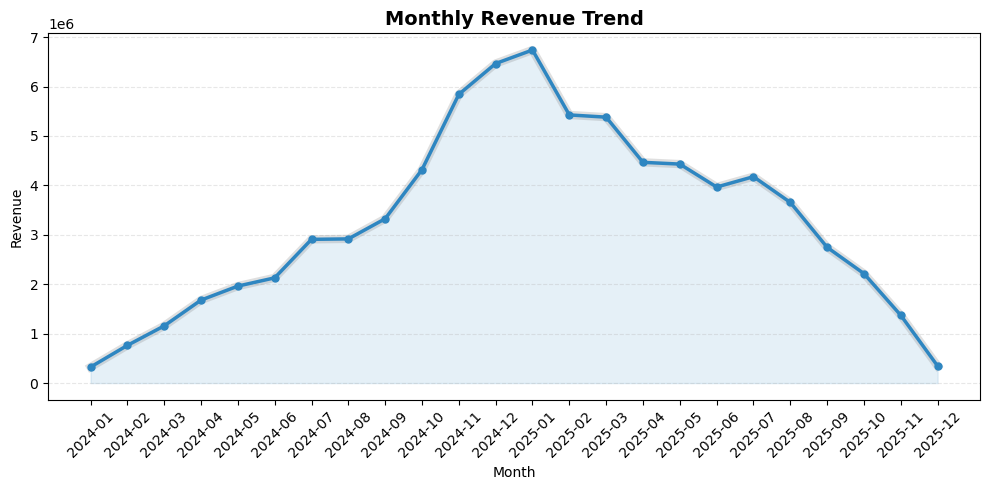

In [9]:
import matplotlib.pyplot as plt

months = monthly_revenue["month"].astype(str)
revenue = monthly_revenue["revenue"]

plt.figure(figsize=(10,5))

# shadow line
plt.plot(months, revenue,
         linewidth=6,
         color="gray",
         alpha=0.25)

# main revenue line
plt.plot(months, revenue,
         color="#2E86C1",
         linewidth=2.5,
         marker="o",
         markersize=5)

# soft fill under line
plt.fill_between(months, revenue,
                 color="#2E86C1",
                 alpha=0.12)

plt.title("Monthly Revenue Trend",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## Generating Key Metrics

In [10]:
# Total Revenue
total_revenue = sales[sales["item_status"] == "Completed"]["revenue"].sum()

# Total Orders
total_orders = sales["order_id"].nunique()

# Average Order Value
aov = total_revenue / total_orders

# Return Rate
return_rate = (sales["item_status"] == "Returned").sum() / len(sales)

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("AOV:", round(aov,2))
print("Return Rate:", round(return_rate,2))

Total Revenue: 78703083.9
Total Orders: 21084
AOV: 3732.83
Return Rate: 0.18


## Automatically Detect Top Category

In [11]:
category_revenue = (
    sales[sales["item_status"] == "Completed"]
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_category = category_revenue.idxmax()
top_category_revenue = category_revenue.max()

print("Top Category:", top_category)
print("Revenue:", top_category_revenue)

Top Category: Footwear
Revenue: 52355214.61


## Automatically Detect Top Product

In [12]:
top_products = (
    sales[sales["item_status"]=="Completed"]
    .groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_product = top_products.idxmax()
top_product_revenue = top_products.max()

print("Top Product:", top_product)

Top Product: Product_21


## AI-Style Insight Generator

In [13]:
insight = f"""
Automated Business Insights

Total revenue generated from completed orders is {total_revenue:,.0f}.

The highest revenue genrating category is {top_category}, contributing {top_category_revenue:,.0f} in sales.

The top perfoming product is {top_product}.

The return rate across all products is {round(return_rate*100,2)}%.

Revenue trends shows changes driven primarily by order volume rather than price changes.
"""
print(insight)


Automated Business Insights

Total revenue generated from completed orders is 78,703,084.

The highest revenue genrating category is Footwear, contributing 52,355,215 in sales.

The top perfoming product is Product_21.

The return rate across all products is 18.03%.

Revenue trends shows changes driven primarily by order volume rather than price changes.



## Save Insights as JSON

In [14]:
import json

insights = {
    "total_revenue": float(total_revenue),
    "total_orders": int(total_orders),
    "average_order_value": float(aov),
    "return_rate": float(return_rate),
    "top_category": top_category,
    "top_product": top_product
}

with open("business_insights.json","w") as f:
    json.dump(insights,f,indent=4)

print("Insights saved.")

Insights saved.
